# Fashion-MNIST 分类（GPU）

数据 / 模型 / 损失 / 优化器 / 评估 / 可视化 全在这个 notebook 里。
曲线用 d2l 的 `Animator`，每个 epoch 训完立刻更新一次。

In [1]:
import numpy as np
import torch
from torch import nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from d2l import torch as d2l


d2l.use_svg_display = lambda: None

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('gpu:', torch.cuda.get_device_name(0))

torch.manual_seed(42)

BATCH_SIZE = 256
NUM_WORKERS = 0   # notebook 里先设 0 最稳；想要快改成 2~4

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.2860,), std=(0.3530,)),
])

train_set = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_iter = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
test_iter = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))

len(train_iter), len(test_iter)

device: cuda
gpu: NVIDIA GeForce RTX 4060 Laptop GPU


(235, 40)

In [4]:
NUM_CLASSES = 10
LR =0.5

net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, NUM_CLASSES),
).to(device)

loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=LR)
# 想用 SGD 的话 lr 得给到 0.5 左右，1e-3 配 SGD 基本学不动

In [5]:
@torch.no_grad()
def evaluate(net, data_iter):
    """返回 (平均损失, 准确率)。一个 epoch 只调一次，别放进 batch 循环。"""
    net.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for X, y in data_iter:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        y_hat = net(X)
        loss_sum += loss(y_hat, y).item() * y.numel()
        correct += (y_hat.argmax(dim=1) == y).sum().item()
        total += y.numel()
    net.train()
    return loss_sum / total, correct / total

In [6]:
import matplotlib.pyplot as plt

CLASSES = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
           'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']


def show_images(dataset, n=32, cols=8, start=0):
    """画数据集里的前 n 张图，带类别名。"""
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.7))
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i >= n:
            continue
        idx = (start + i) % len(dataset)
        ax.imshow(dataset.data[idx], cmap='gray')
        ax.set_title(CLASSES[int(dataset.targets[idx])], fontsize=9)
    fig.tight_layout()
    return fig


def _curve(ax, values, label, color, marker):
    if values is None or len(values) == 0:
        return
    epochs = list(range(1, len(values) + 1))
    ax.plot(epochs, values, marker + '-', color=color, label=label)
    if len(epochs) <= 20:
        ax.set_xticks(epochs)


def plot_history(*, train_loss=None, test_loss=None, train_acc=None, test_acc=None,
                 figsize=(11, 4)):
    """一次性的静态曲线：左图 loss、右图 acc，刻度分开。训练完再调。"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    _curve(ax1, train_loss, 'train loss', 'tab:red', 'o')
    _curve(ax1, test_loss, 'test loss', 'tab:orange', 's')
    ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.set_title('loss'); ax1.grid(alpha=0.3)

    _curve(ax2, train_acc, 'train acc', 'tab:blue', 'o')
    _curve(ax2, test_acc, 'test acc', 'tab:green', 's')
    ax2.set_xlabel('epoch'); ax2.set_ylabel('acc'); ax2.set_title('accuracy'); ax2.grid(alpha=0.3)

    for ax in (ax1, ax2):
        if ax.get_legend_handles_labels()[0]:
            ax.legend()
    fig.tight_layout()
    return fig


@torch.no_grad()
def confusion_matrix(net, data_iter):
    """返回 10x10 混淆矩阵，行是真值、列是预测。"""
    net.eval()
    cm = torch.zeros(100, dtype=torch.long)
    for X, y in data_iter:
        pred = net(X.to(device)).argmax(dim=1).cpu()
        cm += torch.bincount(y * 10 + pred, minlength=100)
    net.train()
    return cm.reshape(10, 10).numpy()


def plot_confusion(cm, figsize=(7.5, 6)):
    """画混淆矩阵，返回 (fig, 每类准确率)。"""
    cm = np.asarray(cm)
    per_class = np.diag(cm) / cm.sum(axis=1).clip(min=1)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(10), labels=CLASSES, rotation=45, ha='right')
    ax.set_yticks(range(10), labels=CLASSES)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')

    thresh = cm.max() / 2
    for i in range(10):
        for j in range(10):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8,
                        color='white' if cm[i, j] > thresh else 'black')
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    return fig, per_class

In [7]:
# d2l 的 Animator：边训边更新。只画一个坐标轴、最多 4 条线（fmts 就 4 个）。
def make_animator(num_epochs, figsize=(6, 4)):
    return d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                        legend=['train loss', 'test loss', 'train acc', 'test acc'],
                        figsize=figsize)

epoch 10 | train loss 0.2342 acc 0.9109 | test loss 0.3451 acc 0.8786


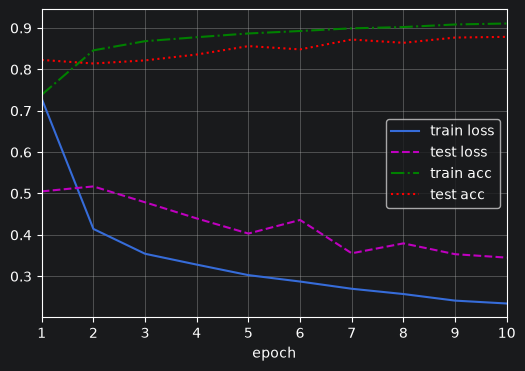

In [8]:
num_epochs = 10
animator = make_animator(num_epochs)
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(num_epochs):
    net.train()
    loss_sum, correct, total = 0.0, 0, 0
    for X, y in train_iter:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        y_hat = net(X)
        l = loss(y_hat, y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()

        loss_sum += l.item() * y.numel()
        correct += (y_hat.argmax(dim=1) == y).sum().item()
        total += y.numel()

    train_loss, train_acc = loss_sum / total, correct / total
    test_loss, test_acc = evaluate(net, test_iter)
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    animator.add(epoch + 1, (train_loss, test_loss, train_acc, test_acc))
    print(f'epoch {epoch+1:2d} | train loss {train_loss:.4f} acc {train_acc:.4f} '
          f'| test loss {test_loss:.4f} acc {test_acc:.4f}')

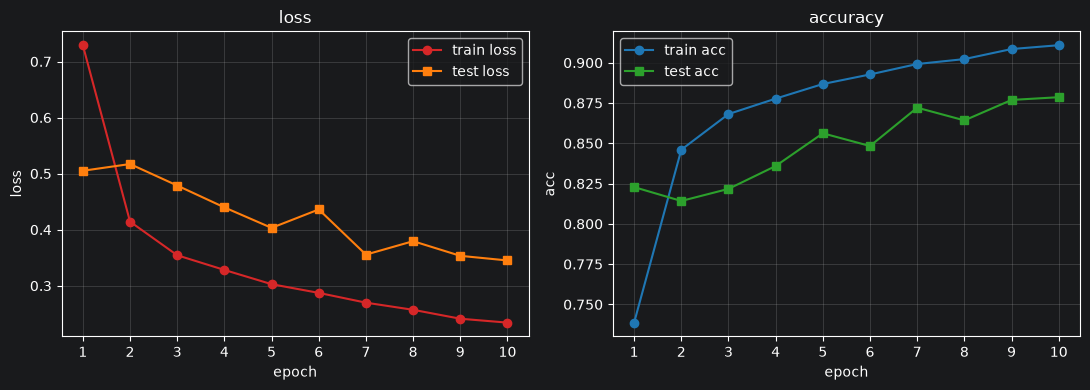

In [9]:
plot_history(**history)
plt.show()

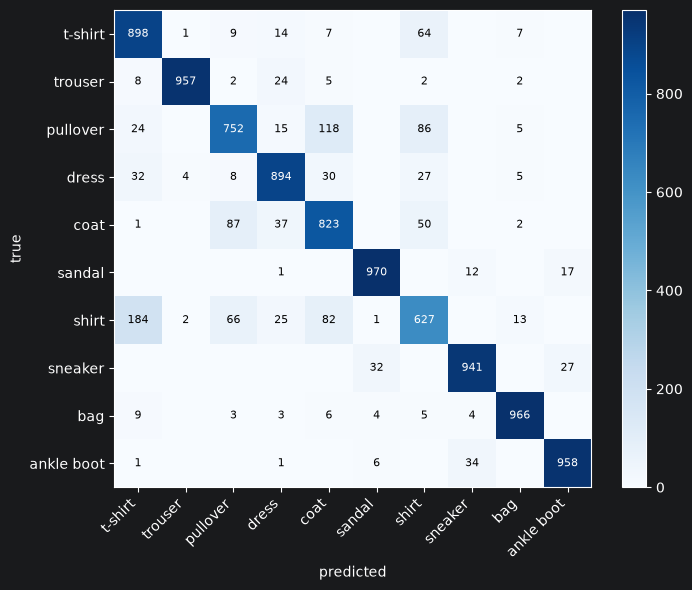

t-shirt      0.898
trouser      0.957
pullover     0.752
dress        0.894
coat         0.823
sandal       0.970
shirt        0.627
sneaker      0.941
bag          0.966
ankle boot   0.958


In [10]:
fig, per_class = plot_confusion(confusion_matrix(net, test_iter))
plt.show()
for name, acc in zip(CLASSES, per_class):
    print(f'{name:12s} {acc:.3f}')

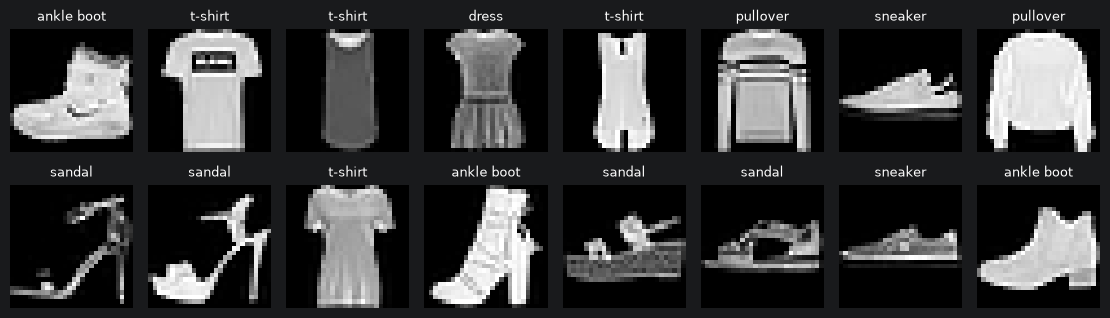

In [11]:
show_images(train_set, n=16, cols=8)
plt.show()

## 对照实验：优化器与层数

同一份数据、同一个 `torch.manual_seed(42)`、同一批顺序，只改一个变量。

### 1. 优化器：SGD lr=0.5 vs Adam lr=1e-3

2 隐藏层 256-128，10 epoch：

| 优化器 | 参数量 | 最后 test acc | train/test gap | 最后 test loss |
|---|---|---|---|---|
| SGD `lr=0.5` | 235,146 | 0.8852 | **+2.99 pt** | 0.3355 |
| Adam `lr=1e-3` | 235,146 | **0.8870** | +3.50 pt | 0.3300 |

逐 epoch test acc：

```
SGD   0.7280 0.8396 0.8394 0.8729 0.8640 0.8510 0.8570 0.8740 0.8720 0.8852
Adam  0.8404 0.8633 0.8701 0.8753 0.8791 0.8828 0.8807 0.8798 0.8846 0.8870
```

终点几乎打平（差 0.18 pt），但**过程完全不同**：

- SGD 的 test acc 在 +-1.5 pt 里来回跳（第 5 到第 6 轮 0.8640 -> 0.8510 又回升），test loss 第一轮 0.8167、之后 0.44 / 0.36 / 0.42 上下翻。
- Adam 从 0.8404 单调爬到 0.8870，test loss 平滑压到 0.3300。
- 第一轮差距最大：SGD 的 train acc 只有 0.7458，Adam 已经 0.8130。

所以「SGD 得给到 0.5」是对的，但 **lr=0.5 的裸 SGD 只是「能走」，很吵**，配上 `momentum=0.9` 或学习率衰减才顺。

### 2. 隐藏层数：2 层 vs 3 层

都用 Adam `lr=1e-3`，10 epoch：

| 网络结构 | 参数量 | 最后 test acc | gap | 最后 test loss |
|---|---|---|---|---|
| 784-256-128-10（2 隐藏层） | 235,146 | 0.8870 | +3.50 pt | 0.3300 |
| 784-256-256-128-10（3 隐藏层） | 300,938 | **0.8910** | **+3.05 pt** | 0.3242 |

多一层换来 **+0.40 pt** test acc，代价是 **+28% 参数**（23.5 万涨到 30.1 万），gap 反而小了 0.45 pt。有收益但很薄，瓶颈不在容量。

曲线见 `optimizer_compare.png`（实线 train、虚线 test，左 acc 右 loss）。
